In [1]:
import warnings
warnings.filterwarnings(action='ignore') 

import datetime
import pandas as pd
import numpy as np
import csv
import folium
from folium.plugins import HeatMap 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
import scipy as sp
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.formula.api as smf
from dateutil.relativedelta import relativedelta
# import setuptools.dist
from yellowbrick.cluster import KElbowVisualizer
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

## 워드클라우드

In [2]:
## Okt

from konlpy.tag import Okt

okt = Okt()
text = "자연어 처리는 정말 재미있어요!"
print(okt.morphs(text))       # 형태소 분리
print(okt.pos(text))          # 품사 태깅
print(okt.nouns(text))        # 명사만 추출

['자연어', '처리', '는', '정말', '재미있어요', '!']
[('자연어', 'Noun'), ('처리', 'Noun'), ('는', 'Josa'), ('정말', 'Noun'), ('재미있어요', 'Adjective'), ('!', 'Punctuation')]
['자연어', '처리', '정말']


In [3]:
from konlpy.tag import Hannanum

h = Hannanum()
text = "자연어 처리는 정말 재미있어요!"
print(h.morphs(text))       # 형태소 분리
print(h.pos(text))          # 품사 태깅
print(h.nouns(text))        # 명사만 추출

['자연어', '처리', '는', '정말', '재미있', '어', '요', '!']
[('자연어', 'N'), ('처리', 'N'), ('는', 'J'), ('정말', 'M'), ('재미있', 'P'), ('어', 'E'), ('요', 'J'), ('!', 'S')]
['자연어', '처리']


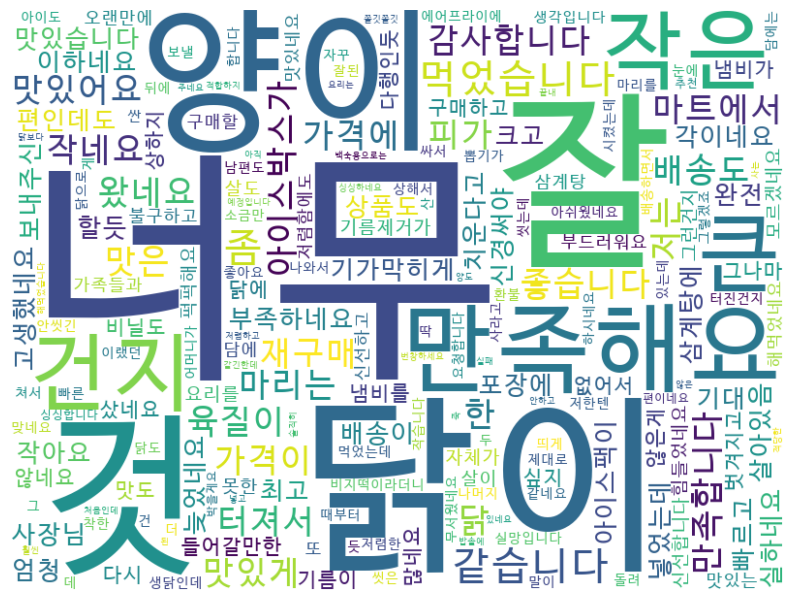

In [4]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# 1. 파일 읽기
txt = open('../../data/wordcloud_001.txt', 'rt', encoding='UTF-8').read()

# 2. 한글과 공백만 남기기 (특수문자 제거)
clean_txt = re.sub(r"[^가-힣\s]", " ", txt)

# 3. 단어 리스트 만들기
words = clean_txt.split() #(공백 기준)

# 4. 단어 빈도 계산
cnt = Counter(words)

# 5. 워드클라우드 생성
wc = WordCloud(
    font_path='/home/erion/.local/share/fonts/d2codingligature-nerd-font/D2CodingLigatureNerdFont-Regular.ttf',  # 폰트 경로 필수!
    background_color='white',
    width=800,
    height=600,
    max_words=200
)

cloud = wc.generate_from_frequencies(cnt)

# 6. 시각화
plt.figure(figsize=(10,8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [5]:
from konlpy.tag import Hannanum

## 1 .데이터 읽어오기
txt = open('../../data/wordcloud_001.txt','rt', encoding='UTF-8').read()

## 2. txt 문서에서 명사만 추출하기
n1 = Hannanum().nouns(txt) 
n1

['닭',
 '최고',
 '육질',
 '배송',
 '상품',
 '기가막히',
 '사장님',
 '감사',
 '닭',
 '양',
 '편',
 '부족',
 '완전',
 '만족',
 '재구',
 '각',
 '삼계탕',
 '양',
 '기대',
 '이하',
 '배송',
 '아이스팩',
 '고생',
 '포장',
 '듯',
 '닭',
 '만',
 '냄비',
 '냄비',
 '맛',
 '아이스박스',
 '비닐',
 '구매',
 '닭',
 '다행',
 '듯',
 '닭',
 '기름제거',
 'ㅠㅠ',
 '살',
 '퍽퍽해요',
 '요리',
 '것',
 '닭',
 '자체',
 '것',
 '신선',
 '살',
 '오랜만',
 '가족들',
 '삼계탕',
 '해먹었네요',
 '감사',
 '가격',
 '저렴함',
 '불구',
 '닭',
 '신선',
 '구매',
 '생각',
 '것',
 '비지떡',
 '말',
 '저한텐',
 '닭',
 '실망',
 '가격',
 '것',
 '저',
 '만족',
 '^0',
 '뒤',
 '에어프라이',
 '소금',
 '남편',
 '아이',
 '양',
 '거',
 '만족',
 '만족',
 '만족',
 '만족',
 '생닭',
 '피',
 '안씻긴',
 '듯',
 '피',
 '배송하',
 '아이스박스',
 '것',
 '때',
 '것',
 '닭',
 '환불',
 '요청',
 '두',
 '마리',
 '마리',
 '데',
 '나머지',
 '마리',
 '눈',
 '가격',
 '저렴한',
 '가격',
 '것',
 '어머니',
 '닭',
 '맛',
 '양',
 'ㅡㅡ',
 '배송',
 '편',
 '싱싱',
 '추천',
 '박을게요',
 '백숙용',
 '적합',
 '것',
 '마트',
 '닭',
 '저',
 '싱싱',
 '양',
 '저',
 '적당',
 '것',
 '번창',
 '밥솥',
 '닭',
 '죽',
 '해먹었습니',
 '처음',
 '실패',
 '안',
 '것',
 '쫄깃쫄깃',
 '육질',
 '재구',
 '예정',
 '것',
 '같긴한데',
 '맛',
 '요리',
 '겉

In [6]:
## 3.글자수가 2개 이상인 단어만 필터링
n2 = [i    for i in n1  if len(i) >= 2]
n2

['최고',
 '육질',
 '배송',
 '상품',
 '기가막히',
 '사장님',
 '감사',
 '부족',
 '완전',
 '만족',
 '재구',
 '삼계탕',
 '기대',
 '이하',
 '배송',
 '아이스팩',
 '고생',
 '포장',
 '냄비',
 '냄비',
 '아이스박스',
 '비닐',
 '구매',
 '다행',
 '기름제거',
 'ㅠㅠ',
 '퍽퍽해요',
 '요리',
 '자체',
 '신선',
 '오랜만',
 '가족들',
 '삼계탕',
 '해먹었네요',
 '감사',
 '가격',
 '저렴함',
 '불구',
 '신선',
 '구매',
 '생각',
 '비지떡',
 '저한텐',
 '실망',
 '가격',
 '만족',
 '^0',
 '에어프라이',
 '소금',
 '남편',
 '아이',
 '만족',
 '만족',
 '만족',
 '만족',
 '생닭',
 '안씻긴',
 '배송하',
 '아이스박스',
 '환불',
 '요청',
 '마리',
 '마리',
 '나머지',
 '마리',
 '가격',
 '저렴한',
 '가격',
 '어머니',
 'ㅡㅡ',
 '배송',
 '싱싱',
 '추천',
 '박을게요',
 '백숙용',
 '적합',
 '마트',
 '싱싱',
 '적당',
 '번창',
 '밥솥',
 '해먹었습니',
 '처음',
 '실패',
 '쫄깃쫄깃',
 '육질',
 '재구',
 '예정',
 '같긴한데',
 '요리',
 '겉모습',
 '마트',
 '차이']

In [7]:
from collections import Counter
## 4. 명사별 빈도 
cnt = Counter(n2)
cnt

Counter({'만족': 6,
         '가격': 4,
         '배송': 3,
         '마리': 3,
         '육질': 2,
         '감사': 2,
         '재구': 2,
         '삼계탕': 2,
         '냄비': 2,
         '아이스박스': 2,
         '구매': 2,
         '요리': 2,
         '신선': 2,
         '싱싱': 2,
         '마트': 2,
         '최고': 1,
         '상품': 1,
         '기가막히': 1,
         '사장님': 1,
         '부족': 1,
         '완전': 1,
         '기대': 1,
         '이하': 1,
         '아이스팩': 1,
         '고생': 1,
         '포장': 1,
         '비닐': 1,
         '다행': 1,
         '기름제거': 1,
         'ㅠㅠ': 1,
         '퍽퍽해요': 1,
         '자체': 1,
         '오랜만': 1,
         '가족들': 1,
         '해먹었네요': 1,
         '저렴함': 1,
         '불구': 1,
         '생각': 1,
         '비지떡': 1,
         '저한텐': 1,
         '실망': 1,
         '^0': 1,
         '에어프라이': 1,
         '소금': 1,
         '남편': 1,
         '아이': 1,
         '생닭': 1,
         '안씻긴': 1,
         '배송하': 1,
         '환불': 1,
         '요청': 1,
         '나머지': 1,
         '저렴한': 1,
         '어머니': 1,

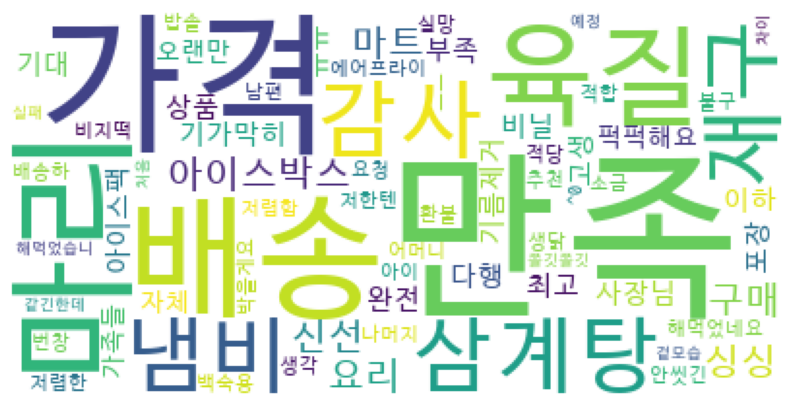

In [8]:
from wordcloud import WordCloud

## 5. 워드클라우드용 폰트 설정
wcs = WordCloud(
                font_path='/home/erion/.local/share/fonts/d2codingligature-nerd-font/D2CodingLigatureNerdFont-Regular.ttf',  # 폰트 경로 필수!
                background_color = 'white', 
                # colormap='RdBu'
                )

## 6. 단어별 빈도로 워드클라우드 생성
cloud = wcs.generate_from_frequencies(cnt)

## 7. 워드클라우드 그리기
import matplotlib.pyplot as plt
plt.figure(figsize = (10,7))
plt.axis('off')
plt.imshow(cloud)